# FINAL PROJECT - Dynamical friction from a Thin Disk

## IMPORT MODULES

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import constants as const
from astropy import units as u

from scipy.stats import norm
from scipy.stats import uniform

In [2]:
## --- FUNCTIONS --- ##

def Couples(arr):
    aa, bb = np.meshgrid(arr, arr)
    mtx = np.stack([aa, bb], axis=-1) # matrix of couples

    n = mtx.shape[0]
    j = np.arange(n)[:, None] # column vector: [[0], [1], [2]]
    i = np.arange(n) # row vector: [0, 1, 2]

    return mtx[j > i] # mask to select upper right triangle

# Gravitational energy (more efficient than using itertools)
def U(m, r):
    mm = Couples(m)
    xx = Couples(r[:, 0])
    yy = Couples(r[:, 1])
    zz = Couples(r[:, 2])

    rr = np.stack([xx, yy, zz], axis=-1)

    return -G * np.sum(mm[:, 0] * mm[:, 1] / np.linalg.norm(rr[:, 0] - rr[:, 1], axis=-1))

# Kinetic energy
def K(m, v):
    return np.sum(m * np.linalg.norm(v, axis=-1)**2 / 2)

## CHOOSE UNITS

The physical system of reference is an 'asteroid' belt orbiting a planet and crossed by some massive object (e.g. a moon)

In [2]:
# Chosen physical units (same name as in astropy https://docs.astropy.org/en/stable/units/#module-astropy.units.astrophys)
units = [100 * u.km, u.s, u.M_earth]

# Physical constants converted to chosen units
G = const.G.to(units[0]**3 / (units[1]**2 * units[2])).value
c = const.c.to(units[0] / units[1]).value
print(' --- PHYSICAL CONSTANTS ---')
print('\nG =', round(G, 5), '\nc =', round(c))

# Conversion constants between physical and internal units
R0 = 1
M0 = 1 # R0**3 / (G * T0**2)
T0 = np.sqrt(R0**3 / (G * M0)) # 1000

print('\n\n --- CONVERSION CONSTANTS ---')
print('\nR0 =', R0, '\nM0 =', M0, '\nT0 =', T0)

 --- PHYSICAL CONSTANTS ---

G = 0.3986 
c = 2998


 --- CONVERSION CONSTANTS ---

R0 = 1 
M0 = 1 
T0 = 1.5839123129056716


# 1 - INPUT

System's parameters are chosen taking into account the resulting integration parameters (see below).

## CENTRAL MASS

Exploiting the gravitational potential of a point mass is an easy way to set up a stable disk.\
Here, a gas giant is considered as reference.

In [3]:
M_cen = 100 # in earth masses

# In the center, at rest
x_cen, y_cen, z_cen = 0, 0, 0
vx_cen, vy_cen, vz_cen = 0, 0, 0

# Circular velocity
def v_c(r):
    return np.sqrt(G * M_cen / r)

## DISK

In [4]:
N = 10000 # number of p.cles

## --- CHARACTERISTIC QUANTITIES --- ##

# Quantities (in physical units) defining the system

R_int = 10**3 * u.km
R_int = R_int.to(units[0]).value # disk internal radius
R_ext = 25 * 10**3 * u.km
R_ext = R_ext.to(units[0]).value # disk external radius

M = .1 * M_cen # total mass of the disk
S0 = M / (2 * np.pi * np.log(R_ext / R_int))

# Mass of the disk as a function of its external radius
def Mass(r):
    return 2 * np.pi * S0 * np.log(r / R_int)

# Radius as inverse function of the mass - m in [0, 1]
def Radius(m):
    return R_int * np.exp(np.log(R_ext / R_int) * m)

# Surface density of the disk
def S(r):
    return S0 / r**2

# Masses - considering N p.cles of equal mass
m_dsk = M / N * np.ones(N)

print(' --- DISK PARAMETERS ---\n')
print('\t\t   units')
print('\t physical\t internal\n')
print('M\t', M, ' \t\t', round(M / M0))
print('m\t', M / N, ' \t', round(M / N / M0, 5))
print('R_int\t', R_int, '\t\t', round(R_int / R0, 5))
print('R_ext\t', R_ext, '\t\t', round(R_ext / R0, 5))
print('vc_int\t', round(v_c(R_int), 2), '\t\t', round(v_c(R_int) / R0 * T0))
print('vc_ext\t', round(v_c(R_ext), 2), '\t\t', round(v_c(R_ext) / R0 * T0, 2))

 --- DISK PARAMETERS ---

		   units
	 physical	 internal

M	 10.0  		 10
m	 0.001  	 0.001
R_int	 10.0 		 10.0
R_ext	 250.0 		 250.0
vc_int	 2.0 		 3
vc_ext	 0.4 		 0.63


In [5]:
## --- SAMPLE POSITION --- ##

rho = Radius(uniform.rvs(size=N))
phi = 2 * np.pi * uniform.rvs(size=N)

x_dsk = rho * np.cos(phi)
y_dsk = rho * np.sin(phi)
z_dsk = np.zeros(N)

### No velocity dispersion

In [23]:
## --- SAMPLE VELOCITIES --- ##

va = v_c(rho) # angular velocity

vx_dsk = - va * np.sin(phi)
vy_dsk = va * np.cos(phi)
vz_dsk = np.zeros(N)

### With velocity dispersion

In [6]:
## --- DISK STABILITY --- ##

# Velocity dispersion (proportional to v_c for consistency)
k_s = .05
def sigma_v(r):
    return k_s * v_c(r)

print(' --- DISK VELOCITIES ---\n')
print('\t\t   units')
print('\t physical\t internal\n')
print('vc_int\t', round(v_c(R_int), 2), '\t\t', round(v_c(R_int) / R0 * T0))
print('sv_int\t', round(sigma_v(R_int), 2), '\t\t', round(sigma_v(R_int) / R0 * T0))
print('vc_ext\t', round(v_c(R_ext), 2), '\t\t', round(v_c(R_ext) / R0 * T0, 2))
print('sv_ext\t', round(sigma_v(R_ext), 2), '\t\t', round(sigma_v(R_ext) / R0 * T0, 2))

# Toomre parameter
Q = k_s * M_cen / (np.pi * S0)

print('\n')
print(' --- TOOMRE PARAMETER ---\n')
print('Q =', round(Q, 2))

 --- DISK VELOCITIES ---

		   units
	 physical	 internal

vc_int	 2.0 		 3
sv_int	 0.1 		 0
vc_ext	 0.4 		 0.63
sv_ext	 0.02 		 0.03


 --- TOOMRE PARAMETER ---

Q = 3.22


In [7]:
## --- SAMPLE VELOCITIES --- ##

vr = v_c(rho) * norm(0, k_s).rvs(size=N)
va = v_c(rho) * norm(1, k_s).rvs(size=N)

vx_dsk = vr * np.cos(phi) - va * np.sin(phi)
vy_dsk = vr * np.sin(phi) + va * np.cos(phi)
vz_dsk = np.zeros(N)

## PERTURBER

In [5]:
Lambda = 2500 # = R_ext * v_per**2 / (G * M_per)
R_per = R_ext / 5

M_per = M_cen * R_ext / Lambda / R_per # computed from Lambda

# Set the position
x_per = R_per
y_per = 0
z_per = 0

# Set the circular velocity
vx_per = 0
vy_per = v_c(R_per)
vz_per = 0

print(' --- PERTURBER ---\n')
print('\t\t   units')
print('\t physical\t internal\n')
print('M_per\t', M_per, '\t\t', M_per / M0)
print('R_per\t', R_per, '\t\t', R_per / M0)
print('v_per\t', round(vy_per, 2), '\t\t', round(vy_per / M0, 2))

 --- PERTURBER ---

		   units
	 physical	 internal

M_per	 0.2 		 0.2
R_per	 50.0 		 50.0
v_per	 0.89 		 0.89


## SET THE SYSTEM

In [13]:
# ADD THE CENTRAL MASS TO THE SYSTEM
N += 1

m = np.hstack((M_cen, m_dsk))

x, y, z = np.hstack((x_cen, x_dsk)), np.hstack((y_cen, y_dsk)), np.hstack((z_cen, z_dsk))

vx, vy, vz = np.hstack((vx_cen, vx_dsk)), np.hstack((vy_cen, vy_dsk)), np.hstack((vz_cen, vz_dsk))

In [14]:
# ADD THE PERTURBER TO THE SYSTEM
N += 1

m = np.hstack((m, M_per))

x, y, z = np.hstack((x, x_per)), np.hstack((y, y_per)), np.hstack((z, z_per))

vx, vy, vz = np.hstack((vx, vx_per)), np.hstack((vy, vy_per)), np.hstack((vz, vz_per))

In [15]:
# Clear variables
del m_dsk, x_dsk, y_dsk, z_dsk, vx_dsk, vy_dsk, vz_dsk, rho, phi, vr, va

### Total energy

In [ ]:
## --- THEORETICAL --- ##

K_th = np.pi * S0 * G * M_cen * (1 / R_int - 1 / R_ext)
U_th = -2 * K_th #- G * M_cen * M_per / R_per
#K_th += M_per * v_c(R_per)**2 / 2

E_th = K_th + U_th

## --- NUMERICAL --- ##

r = np.column_stack((x, y, z))
v = np.column_stack((vx, vy, vz))

K_num = K(m, v)
U_num = U(m, r)
E_num = K_num + U_num

print(' --- SYSTEM ENERGY ---\n')
print('\ttheoretical\tnumerical\n')
print('K\t', round(K_th, 2), '\t', round(K_num, 2))
print('U\t', round(U_th, 2), '\t', round(U_num, 2))
print('E\t', round(E_th, 2), '\t', round(E_num, 2))
print('U / K', U_th / K_th, '\t', U_num / K_num)

## INPUT FILE

In [16]:
# For initial input

file_in = 'FP_data/IFFP_p3_1.txt'

m = m / M0

n_dim = 3 # NOTE: can it be done just in 2D ?
time_in = 0 # initial time

r = np.column_stack((x, y, z)) / R0
v = np.column_stack((vx, vy, vz)) / R0 * T0
with open(file_in, 'w') as file:
    file.write(f'{N}\n')
    file.write(f'{n_dim}\n')
    file.write(f'{time_in}\n')
    np.savetxt(file, m[:,None])
    np.savetxt(file, r)
    np.savetxt(file, v)

In [22]:
# For runs starting from last output

file_in = 'FP_data/IFFP_p2_5.txt'
#file_in = 'FP_test/IFFP_t3_6.txt'

n_dim = 3

with open(file_in, 'w') as file:
    file.write(f'{N}\n')
    file.write(f'{n_dim}\n')
    file.write(f'{time[-1]}\n')
    np.savetxt(file, m[-1,:,None])
    np.savetxt(file, r[-1])
    np.savetxt(file, v[-1])

# Remove last 'block' to append new simulation output

end = len(lines) - n
with open(file_out, 'w') as file:
    file.writelines(lines[:end])

# 2 - INTEGRATION PARAMETERS

Integration parameters estimation for treecode.\
NOTE: parameters must be converted in internal units.

In [9]:
print(' --- ORBITAL PERIODS ---\n')
print('All values in internal units\n')

## --- ORBITAL PERIOD --- ##

# Reference for simulation time. Computed at mean and perturber radius
R_mean = 2 * np.pi * S0 * (R_ext - R_int) / M
T_orb, T_per = 2 * np.pi * R_mean / v_c(R_mean), 2 * np.pi * R_per / vy_per
print('R_mean =', round(R_mean, 2), '\tR_per =', R_per)
print('T_orb =', round(T_orb / T0, 2), '\tT_per =', round(T_per / T0, 2))

print('\nConversion constants: R0 =', R0, 'T0 =', T0, 'M0 =', M0)

 --- ORBITAL PERIODS ---

All values in internal units

R_mean = 74.56 	R_per = 50.0
T_orb = 404.52 	T_per = 222.14

Conversion constants: R0 = 1 T0 = 1.5839123129056716 M0 = 1


In [8]:
## --- DYNAMICAL FRICTION TIMESCALE --- ##

r_i, r_f = R_per, R_per / 2 # range to satisfy disk's case assumptions

# Disk (through numerical integration)

nn = 10**5
xx = Radius(uniform.rvs(size=(100, nn))) / R_per

C1, C2 = 2 * M / N / (M_per + M / N), M_cen / (M_per + M / N)
I = C1 * np.sum((1 - np.sqrt(1 / xx)) / (1 + C2**2 * (xx - 1)**2 * (1 - np.sqrt(1 / xx))**4), axis=-1) / nn

T_frc = (1 / r_i - 1 / r_f) / I
print('T_fric =', round(T_frc.mean() / T0), '+/-', round(T_frc.std() / T0), 'for a disk')

T_fric = 4218 +/- 889 for a disk


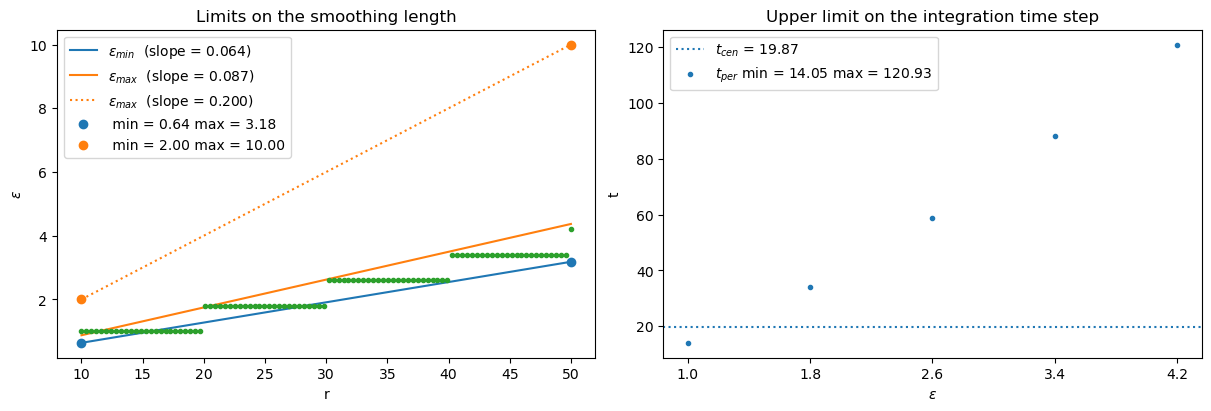

In [25]:
## --- SMOOTHING LENGTH --- ##

beta = 2 / N

r = np.linspace(R_int, R_per, 100)

# Limits on the smoothing length (both functions of the distance from the central mass)
# Upper: from the perturber's influence radius
# Lower: to contain at least 2 p.cles

slope_min, slope_max_1, slope_max_2 = np.sqrt(beta * M / S0), (M_per / 3 / M_cen)**(1/3), (4 * M_per / M_cen)**(1/3)
eps_min, eps_max_1, eps_max_2 = slope_min * r, slope_max_1 * r, slope_max_2 * r

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12,4), layout='constrained')

ax.plot(r, eps_min, label=r'$\epsilon_{min}$' + f'  (slope = {slope_min:.3f})')
ax.plot(r, eps_max_1, label=r'$\epsilon_{max}$' + f'  (slope = {slope_max_1:.3f})')
ax.plot(r, eps_max_2, ':', c='tab:orange', label=r'$\epsilon_{max}$' + f'  (slope = {slope_max_2:.3f})')
ax.scatter(r[::r.size-1], eps_min[::r.size-1], c='tab:blue', label=f' min = {eps_min[0]:.2f} max = {eps_min[-1]:.2f}')
ax.scatter(r[::r.size-1], eps_max_2[::r.size-1], c='tab:orange', label=f' min = {eps_max[0]:.2f} max = {eps_max[-1]:.2f}')

step_size, slope = 10, .08
#step_size, slope = 5, .075
eps = np.floor(r / step_size) * step_size * slope + .2
ax.plot(r, eps, '.')

ax.set_title('Limits on the smoothing length')
ax.set_xlabel('r')
ax.set_ylabel(r'$\epsilon$')

ax.legend()


eps = np.unique(eps)
t_c = 2 * np.pi * np.sqrt(R_int**3 / G / M_cen) # orbital period at R_int
t_p = 2 * np.pi * np.sqrt(eps**3 / G / M_per) # 'orbital period' around the perturber

bx.axhline(t_c / T0, ls=':', label=r'$t_{cen}$' + f' = {t_c / T0:.2f}')
bx.plot(eps, t_p / T0, '.', label=r'$t_{per}$' + f' min = {t_p.min() / T0:.2f} max = {t_p.max() / T0:.2f}')

bx.set_title('Upper limit on the integration time step')
bx.set_xticks(eps)
bx.set_xlabel(r'$\epsilon$')
bx.set_ylabel('t')

bx.legend()

plt.show()

# 3 - ANALYSIS

## OUTPUT FILE

Read the output file, define mass, position and velocity arrays and move to the CoM RF.
NOTE: this block is used for everyone of the analysed systems.

In [2]:
# Read file

file_out = 'FP_data/OFFP_p2_2.txt'
#file_out = 'FP_test/OFFP_t3_2.txt'

time_rows = []
m_rows, r_rows, v_rows = [], [], []
with open(file_out, "r") as file:
    lines = file.readlines()

    N = int(lines[0])
    n = 3 * N + 3 # 'block' length
    m = 3     # number of rows to skip (i.e. lines containing n. bodies and time)
    
    for i in range(0, len(lines), n):  # move through rows every n rows
        time_rows.extend(lines[i+2:i+m])
        m_rows.extend(lines[i+m:i+N+3])
        r_rows.extend(lines[i+N+3:i+2*N+3])
        v_rows.extend(lines[i+2*N+3:i+n])

time = np.loadtxt(time_rows)
print(' --- TIME STEPS ---\n')
print('Number:', time.shape, '\tfrom', time[0], 'to', time[-1])

 --- TIME STEPS ---

Number: (701,) 	from 0.0 to 7000.0


In [3]:
## --- FETCHING DATA --- ##

m = np.loadtxt(m_rows) # masses
m = m.reshape((time.size, N))

r = np.loadtxt(r_rows) # positions
r = r.reshape((time.size, N, 3))

v = np.loadtxt(v_rows) # velocities
v = v.reshape((time.size, N, 3))

# Clear variables
del time_rows, m_rows, r_rows, v_rows

In [4]:
## --- MOVING TO CoM REST FRAME --- ##

x_CM = np.sum(m * r[:,:,0], axis=-1) / np.sum(m, axis=-1)
y_CM = np.sum(m * r[:,:,1], axis=-1) / np.sum(m, axis=-1)
z_CM = np.sum(m * r[:,:,2], axis=-1) / np.sum(m, axis=-1)

r_CM = np.column_stack([x_CM, y_CM, z_CM])

vx_CM = np.sum(m * v[:,:,0], axis=-1) / np.sum(m, axis=-1)
vy_CM = np.sum(m * v[:,:,1], axis=-1) / np.sum(m, axis=-1)
vz_CM = np.sum(m * v[:,:,2], axis=-1) / np.sum(m, axis=-1)

v_CM = np.column_stack([vx_CM, vy_CM, vz_CM])

print(' --- CENTER OF MASS ---\n')
print('Position:', r_CM[0], 'to', r_CM[-1], '\tmean =', r_CM.mean(axis=0))
print('Velocity:', v_CM[0], 'to', v_CM[-1], '\tmean =', v_CM.mean(axis=0))

r_CMF = (r.transpose((1,0,2)) - r_CM).transpose((1,0,2)) # transpose to perform array difference
v_CMF = (v.transpose((1,0,2)) - v_CM).transpose((1,0,2))

# Clear variables
del x_CM, y_CM, z_CM, vx_CM, vy_CM, vz_CM 

 --- CENTER OF MASS ---

Position: [ 0.05981701 -0.10021274  0.        ] to [24.90122987  8.61159607  0.        ] 	mean = [11.84418973  9.57134486  0.        ]
Velocity: [0.00030379 0.00153313 0.        ] to [ 0.00389531 -0.00133594  0.        ] 	mean = [0.0035466  0.00124277 0.        ]


## NO PERTURBER

### No dispersion

Input file:    'IFFP_d1_1.txt'
    
Output file:    'OFFP_d1_3.txt'\
With integration parameters: `dtime=1 eps=4 theta=0.5 tstop=3000 dtout=10`

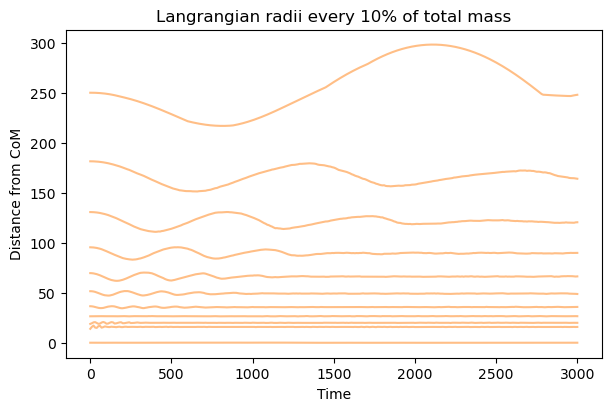

In [15]:
## --- LANGRANGIAN RADII vs TIME (in the CoM RF)--- ##

fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

d_CMF = np.linalg.norm(r_CMF, axis=2)
d_sort = np.sort(d_CMF, axis=1)

ii = int(d_sort.shape[1] / 10)
ax.plot(time, d_sort[:,::ii], color='tab:orange', alpha=.5)

ax.set_title(f'Langrangian radii every {N / ii:.0f}% of total mass')
ax.set_xlabel('Time')
ax.set_ylabel('Distance from CoM')

plt.show()

### With dispersion

Input file:    'IFFP_d2_1.txt'
    
Output file:    'OFFP_d2_5.txt'\
With integration parameters: `dtime=1/2 eps=4 theta=0.5 tstop=5000 dtout=10`\
No fragmentation observed.

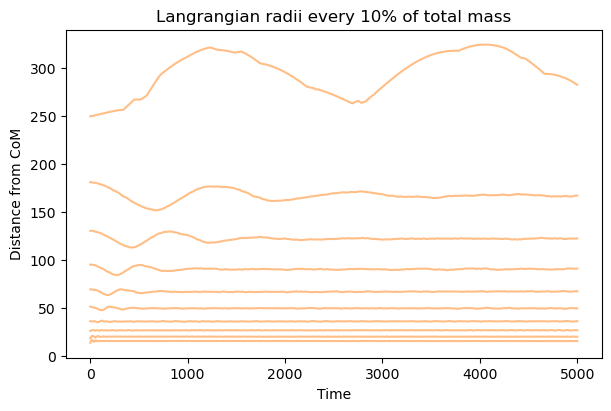

In [33]:
## --- LANGRANGIAN RADII vs TIME (in the CoM RF)--- ##

fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

d_CMF = np.linalg.norm(r_CMF, axis=2)
d_sort = np.sort(d_CMF, axis=1)

ii = int(d_sort.shape[1] / 10)
ax.plot(time, d_sort[:,ii-1::ii], color='tab:orange', alpha=.5)

ax.set_title(f'Langrangian radii every {N / ii:.0f}% of total mass')
ax.set_xlabel('Time')
ax.set_ylabel('Distance from CoM')

#plt.savefig('FP_images/fig_d2_5_LR.png', dpi=200)
plt.show()

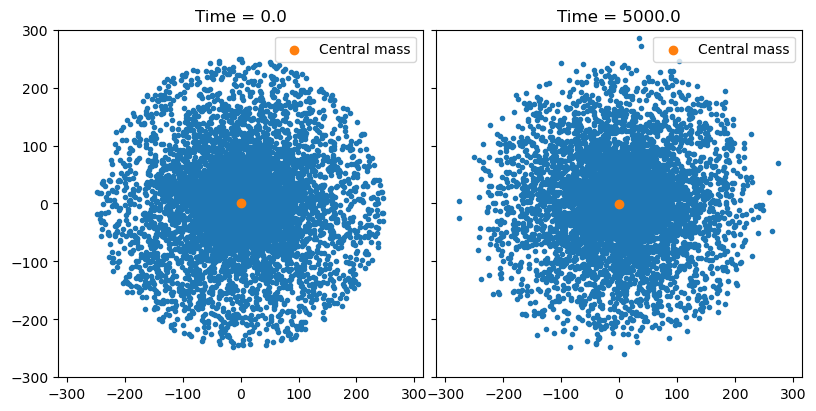

In [17]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout='constrained')

ax.scatter(r_CMF[0, 1:-1, 0], r_CMF[0, 1:-1, 1], marker='.')
ax.scatter(r_CMF[0, 0, 0], r_CMF[0, 0, 1], label='Central mass')
#    ax.scatter(r_CMF[ii, -1, 0], r_CMF[ii, -1, 1], label='Perturber')
#    ax.quiver(r_CMF[ii, 1:, 0], r_CMF[ii, 1:, 1], v_CMF[ii, 1:, 0], v_CMF[ii, 1:, 1])
    
ax.axis('equal')
ax.set_xlim(-300, 300)
ax.set_ylim(-300, 300)

ax.set_title(f'Time = {time[0]}')
ax.legend(loc=1)

bx.scatter(r_CMF[-1, 1:-1, 0], r_CMF[-1, 1:-1, 1], marker='.')
bx.scatter(r_CMF[-1, 0, 0], r_CMF[-1, 0, 1], label='Central mass')
#    ax.scatter(r_CMF[ii, -1, 0], r_CMF[ii, -1, 1], label='Perturber')
#    ax.quiver(r_CMF[ii, 1:, 0], r_CMF[ii, 1:, 1], v_CMF[ii, 1:, 0], v_CMF[ii, 1:, 1])
    
bx.axis('equal')
bx.set_xlim(-300, 300)
bx.set_ylim(-300, 300)

bx.set_title(f'Time = {time[-1]}')
bx.legend(loc=1)

plt.savefig('FP_images/fig_d2_5.png', dpi=200)
plt.show()

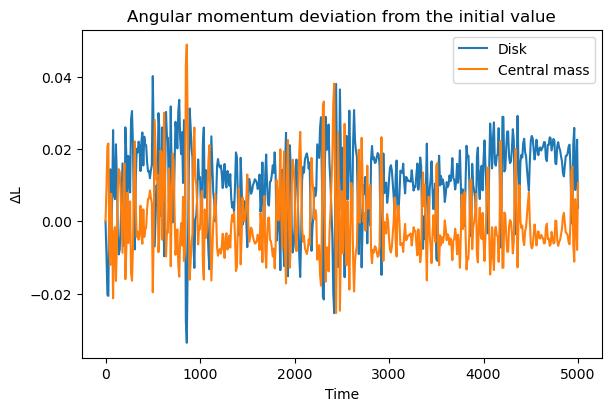

In [13]:
## --- ANGULAR MOMENTUM ANALYSIS --- ##

fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

L = m * np.cross(r_CMF, v_CMF)[:,:,2]

dl_dsk = np.sum(L[:,1:] - L[0,1:], axis=1)
dl_cen = L[:,0] - L[0,0]

ax.plot(time, dl_dsk, label='Disk')
ax.plot(time, dl_cen, label='Central mass')

ax.set_title('Angular momentum deviation from the initial value')
ax.set_xlabel('Time')
ax.set_ylabel(r'$\Delta$L')
ax.legend()

plt.show()

## WITH PERTURBER

After 1500 ITUs (Internal Time Unit), if the perturber is within the next radii range (or reasonably near), `eps` is changed. Else, stop each 500 ITUs until `eps` update (see the section INTEGRATION PARAMETERS above).

### No dispersion

Input file: 'IFFP_p1_1.txt'

Output file: 'OFFP_p1_2.txt'\
With integration parameters: `dtime=1/2 theta=0.5 dtout=10`

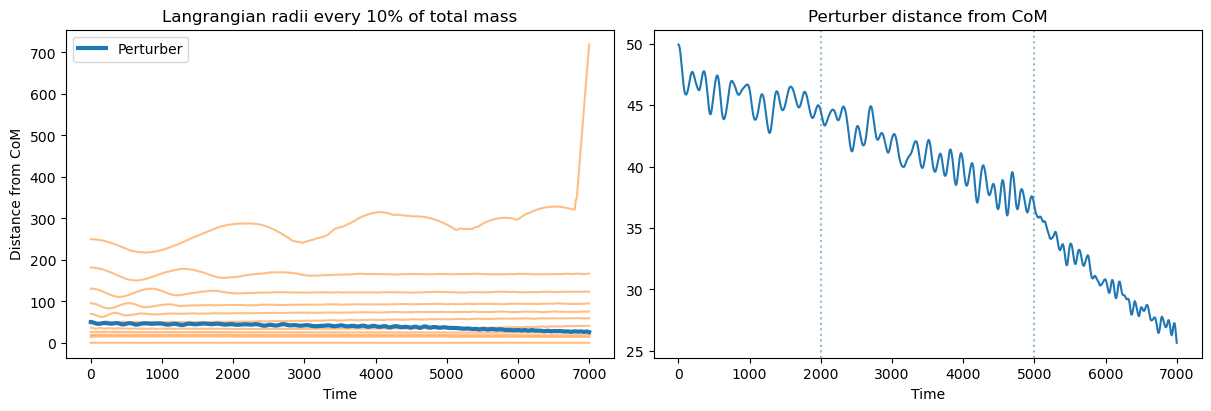

In [5]:
## --- LANGRANGIAN RADII vs TIME (in the CMF)--- ##

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

d_CMF = np.linalg.norm(r_CMF, axis=2)
d_sort = np.sort(d_CMF, axis=1)

ii = int(d_sort.shape[1] / 10)
ax.plot(time, d_sort[:,::ii], color='tab:orange', alpha=.5)
ax.plot(time, d_CMF[:, -1], lw=3, label='Perturber')

ax.set_title(f'Langrangian radii every {N / ii:.0f}% of total mass')
ax.set_xlabel('Time')
ax.set_ylabel('Distance from CoM')
ax.legend()

bx.plot(time, d_CMF[:, -1])
bx.axvline(2000, ls=':', alpha=.5)
bx.axvline(5000, ls=':', alpha=.5)

bx.set_title('Perturber distance from CoM')
bx.set_xlabel('Time')
#bx.legend();

#plt.savefig('FP_images/fig_p1_2_LR.png', dpi=200)
plt.show()

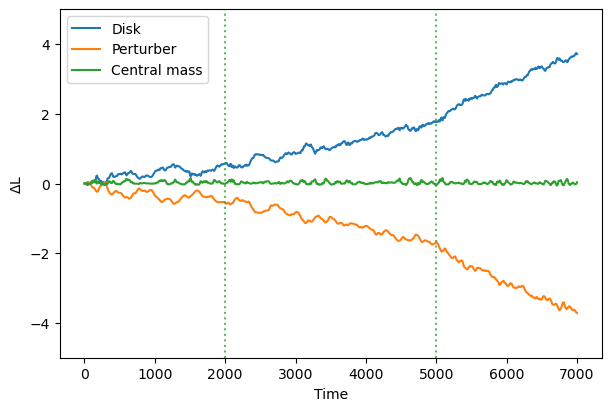

In [9]:
## --- ANGULAR MOMENTUM ANALYSIS --- ##

fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

L = m * np.cross(r_CMF, v_CMF)[:,:,2]

dl_dsk = np.sum(L[:,1:-1] - L[0,1:-1], axis=1)
dl_per = L[:,-1] - L[0,-1]
dl_cen = L[:,0] - L[0,0]

ax.plot(time, dl_dsk, label='Disk')
ax.plot(time, dl_per, label='Perturber')
ax.plot(time, dl_cen, label='Central mass')

ax.axvline(2000, ls=':', color='tab:green', alpha=.75)
ax.axvline(5000, ls=':', color='tab:green', alpha=.75)

ax.set_ylim(-5,5)

#ax.set_title('Angular momentum deviation from the initial value')
ax.set_xlabel('Time')
ax.set_ylabel(r'$\Delta$L')
ax.legend()

plt.savefig('FP_images/fig_p1_2_AM.png', dpi=200)
plt.show()

### With dispersion

Input file: 'IFFP_p2_n.txt' with n $\in$ [1, ...]

Output file: 'OFFP_p2_1.txt'\
With integration parameters: `dtime=1/2 theta=0.5 dtout=10`

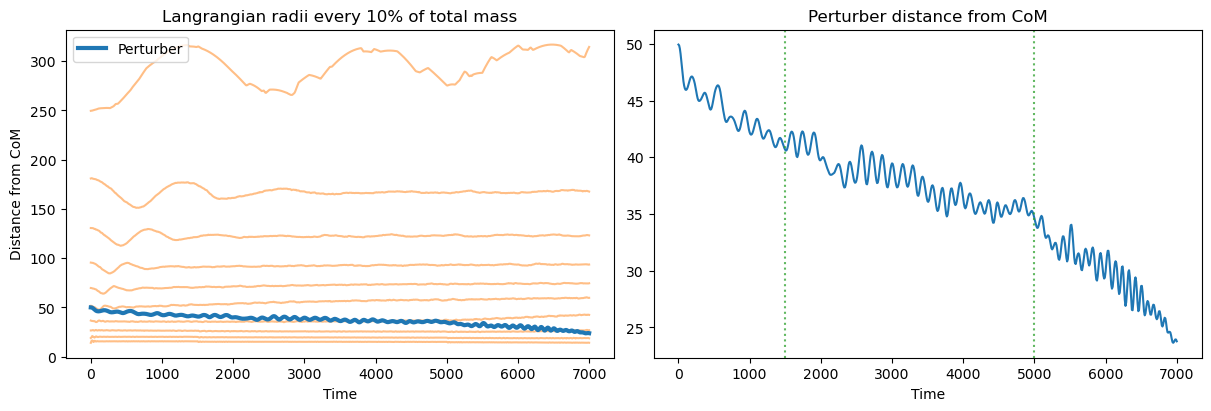

In [10]:
## --- LANGRANGIAN RADII vs TIME (in the CMF)--- ##

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

d_CMF = np.linalg.norm(r_CMF, axis=2)
d_sort = np.sort(d_CMF, axis=1)

ii = int(d_sort.shape[1] / 10)
ax.plot(time, d_sort[:,ii-1::ii], color='tab:orange', alpha=.5)
ax.plot(time, d_CMF[:, -1], lw=3, label='Perturber')

ax.set_title(f'Langrangian radii every {N / ii:.0f}% of total mass')
ax.set_xlabel('Time')
ax.set_ylabel('Distance from CoM')
ax.legend()

bx.plot(time, d_CMF[:, -1])

bx.axvline(1500, ls=':', color='tab:green', alpha=.75)
bx.axvline(5000, ls=':', color='tab:green', alpha=.75)

bx.set_title('Perturber distance from CoM')
bx.set_xlabel('Time')
#bx.legend();

#plt.savefig('FP_images/fig_p2_2_LR.png', dpi=200)
plt.show()

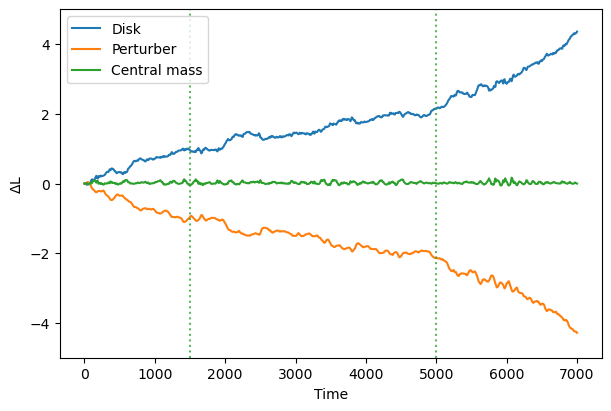

In [9]:
## --- ANGULAR MOMENTUM ANALYSIS --- ##

fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

L = m * np.cross(r_CMF, v_CMF)[:,:,2]

dl_dsk = np.sum(L[:,1:-1] - L[0,1:-1], axis=1)
dl_per = L[:,-1] - L[0,-1]
dl_cen = L[:,0] - L[0,0]

ax.plot(time, dl_dsk, label='Disk')
ax.plot(time, dl_per, label='Perturber')
ax.plot(time, dl_cen, label='Central mass')

ax.axvline(1500, ls=':', color='tab:green', alpha=.75)
ax.axvline(5000, ls=':', color='tab:green', alpha=.75)

ax.set_ylim(-5,5)

#ax.set_title('Angular momentum deviation from the initial value')
ax.set_xlabel('Time')
ax.set_ylabel(r'$\Delta$L')
ax.legend(loc=2)

#plt.savefig('FP_images/fig_p2_2_AM.png', dpi=200)
plt.show()

### Using influence radius approximation

Input: 'IFFP_p2_1.txt'

Output: 'OFFP_p2_3.txt'\
With integration parameters:`dtime=1/2 eps=4 theta=0.5 dtout=10`

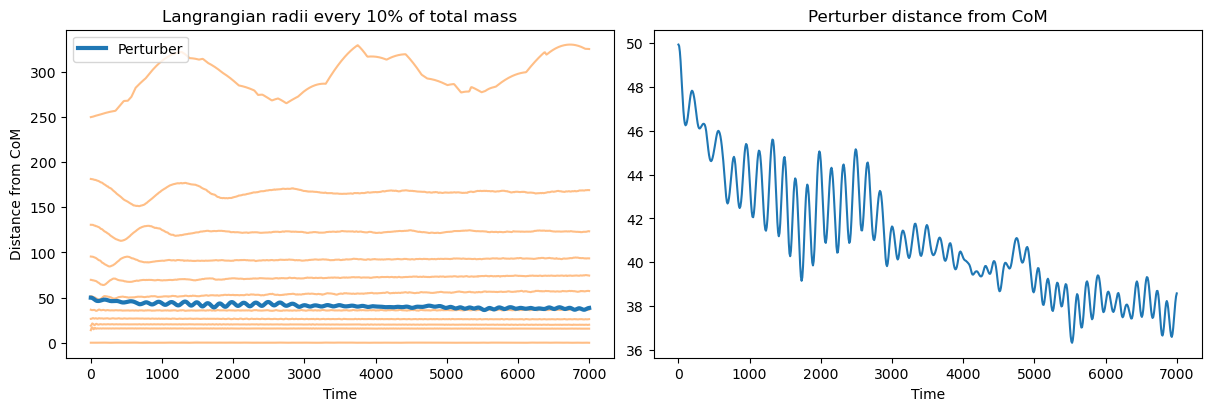

In [6]:
## --- LANGRANGIAN RADII vs TIME (in the CMF)--- ##

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

d_CMF = np.linalg.norm(r_CMF, axis=2)
d_sort = np.sort(d_CMF, axis=1)

ii = int(d_sort.shape[1] / 10)
ax.plot(time, d_sort[:,::ii], color='tab:orange', alpha=.5)
ax.plot(time, d_CMF[:, -1], lw=3, label='Perturber')

ax.set_title(f'Langrangian radii every {N / ii:.0f}% of total mass')
ax.set_xlabel('Time')
ax.set_ylabel('Distance from CoM')
ax.legend()

bx.plot(time, d_CMF[:, -1])

bx.set_title('Perturber distance from CoM')
bx.set_xlabel('Time')
#bx.legend();

#plt.savefig('FP_images/fig_p2_3_LR.png', dpi=200)
plt.show()

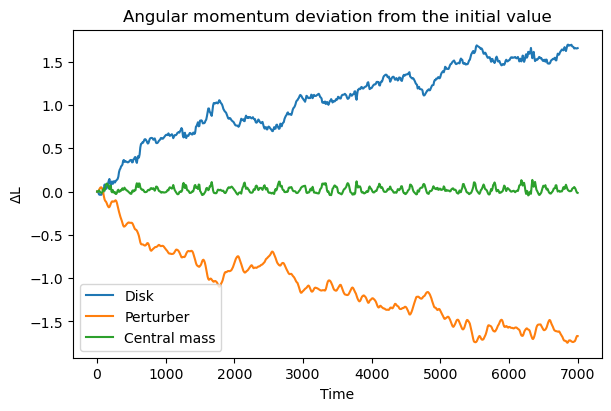

In [7]:
## --- ANGULAR MOMENTUM ANALYSIS --- ##

fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

L = m * np.cross(r_CMF, v_CMF)[:,:,2]

dl_dsk = np.sum(L[:,1:-1] - L[0,1:-1], axis=1)
dl_per = L[:,-1] - L[0,-1]
dl_cen = L[:,0] - L[0,0]

ax.plot(time, dl_dsk, label='Disk')
ax.plot(time, dl_per, label='Perturber')
ax.plot(time, dl_cen, label='Central mass')

ax.set_title('Angular momentum deviation from the initial value')
ax.set_xlabel('Time')
ax.set_ylabel(r'$\Delta$L')
ax.legend()

#plt.savefig('FP_images/fig_p2_3_AM.png', dpi=200)
plt.show()